# Mid-season forecast of the 2015/2016 Premier League

This notebook section uses the baseline model from `src/model.py` to forecast the second half of the 2015/2016 Premier League season.

The model is deliberately simple: each team has one latent strength, there is one global home advantage, and home/away goals are Poisson distributed. We train on all EPL matches before 2015/2016 plus the first half of 2015/2016, then forecast stages 20-38.

Following the latest project decision, Bournemouth and Watford are completely excluded from this baseline analysis. That gives a complete-case 18-team 2015/2016 subset where every forecast team has historical EPL data before the forecast window.


## 1. Setup

The path logic below works whether the notebook is launched from the project root or from the `notebooks` folder. The dependency check is intentionally explicit because the model section needs PyTorch and Pyro.


In [1]:
from pathlib import Path
import importlib.util
import sys


def find_project_root(start_path):
    start_path = Path(start_path).resolve()
    candidates = [start_path, *start_path.parents]
    for candidate in candidates:
        if (candidate / "data" / "epl_matches.csv").exists() and (candidate / "src" / "model.py").exists():
            return candidate
    raise FileNotFoundError("Could not find project root containing data/epl_matches.csv and src/model.py")


PROJECT_ROOT = find_project_root(Path.cwd())
DATA_DIR = PROJECT_ROOT / "data"
SRC_DIR = PROJECT_ROOT / "src"

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

required_packages = {
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "torch": "torch",
    "pyro": "pyro-ppl",
}

missing_packages = [
    install_name
    for import_name, install_name in required_packages.items()
    if importlib.util.find_spec(import_name) is None
]

if missing_packages:
    raise ImportError(
        "Missing required packages for this notebook section: "
        + ", ".join(missing_packages)
        + ". Install them in the active notebook kernel environment."
    )

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import pyro
from pyro.infer import SVI, Trace_ELBO, Predictive
from pyro.infer.autoguide import AutoDiagonalNormal
from pyro.optim import Adam

from model import FootballModel

plt.style.use("ggplot")
pd.set_option("display.max_columns", None)

DATA_PATH = DATA_DIR / "epl_matches.csv"
DATA_PATH


WindowsPath('C:/Users/Madsl/Dropbox/DTU/Kand/3.Semester/MBML/Project_MBML/data/epl_matches.csv')

## 2. Load data and create the mid-season split

We exclude Bournemouth and Watford before training, prediction, table simulation, or evaluation. The 2015/2016 first half is stages 1-19, and the forecast period is stages 20-38.


In [2]:
TEST_SEASON = "2015/2016"
FIRST_HALF_MAX_STAGE = 19
EXCLUDED_TEAMS = {"Bournemouth", "Watford"}

df_raw = pd.read_csv(DATA_PATH, parse_dates=["date"])
expected_columns = [
    "season",
    "stage",
    "date",
    "home_team",
    "away_team",
    "home_team_goal",
    "away_team_goal",
]

assert list(df_raw.columns) == expected_columns, "Unexpected EPL match CSV schema."
assert len(df_raw) == 3040, "Expected 3,040 EPL matches from 2008/2009 through 2015/2016."
assert df_raw.isna().sum().sum() == 0, "Unexpected missing values in epl_matches.csv."

df = df_raw.copy()
df["season"] = df["season"].astype(str)
df["stage"] = df["stage"].astype(int)
df["home_team_goal"] = df["home_team_goal"].astype(int)
df["away_team_goal"] = df["away_team_goal"].astype(int)
df = df.sort_values(["date", "stage", "home_team", "away_team"]).reset_index(drop=True)

team_is_excluded = df["home_team"].isin(EXCLUDED_TEAMS) | df["away_team"].isin(EXCLUDED_TEAMS)
df_model = df.loc[~team_is_excluded].copy()
excluded_matches_df = df.loc[team_is_excluded].copy()

season_2015_df = df_model.loc[df_model["season"] == TEST_SEASON].copy()
first_half_2015_df = season_2015_df.loc[season_2015_df["stage"] <= FIRST_HALF_MAX_STAGE].copy()
second_half_2015_df = season_2015_df.loc[season_2015_df["stage"] > FIRST_HALF_MAX_STAGE].copy()
historical_df = df_model.loc[df_model["season"] != TEST_SEASON].copy()
train_df = pd.concat([historical_df, first_half_2015_df], ignore_index=True)

stage_counts_2015 = df.loc[df["season"] == TEST_SEASON, "stage"].value_counts().sort_index()
assert stage_counts_2015.index.tolist() == list(range(1, 39)), "2015/2016 should contain stages 1-38."
assert (stage_counts_2015 == 10).all(), "Each 2015/2016 stage should contain 10 matches before exclusions."
assert len(first_half_2015_df) == 153, "Expected 153 retained first-half matches after excluding Bournemouth/Watford."
assert len(second_half_2015_df) == 153, "Expected 153 retained second-half matches after excluding Bournemouth/Watford."

split_summary = pd.DataFrame(
    [
        {"dataset": "all EPL matches", "matches": len(df)},
        {"dataset": "excluded Bournemouth/Watford fixtures", "matches": len(excluded_matches_df)},
        {"dataset": "modeling data after exclusions", "matches": len(df_model)},
        {"dataset": "historical training seasons", "matches": len(historical_df)},
        {"dataset": "2015/2016 first half training", "matches": len(first_half_2015_df)},
        {"dataset": "total training data", "matches": len(train_df)},
        {"dataset": "2015/2016 second half forecast", "matches": len(second_half_2015_df)},
    ]
)

display(split_summary)
display(first_half_2015_df.head())
display(second_half_2015_df.head())


,dataset,matches
0,all EPL matches,3040
1,excluded Bournemouth/Watford fixtures,74
2,modeling data after exclusions,2966
3,historical training seasons,2660
4,2015/2016 first half training,153
5,total training data,2813
6,2015/2016 second half forecast,153


,season,stage,date,home_team,away_team,home_team_goal,away_team_goal
2661,2015/2016,1,2015-08-08,Chelsea,Swansea City,2,2
2663,2015/2016,1,2015-08-08,Leicester City,Sunderland,4,2
2664,2015/2016,1,2015-08-08,Manchester United,Tottenham Hotspur,1,0
2665,2015/2016,1,2015-08-08,Norwich City,Crystal Palace,1,3
2666,2015/2016,1,2015-08-09,Arsenal,West Ham United,0,2


,season,stage,date,home_team,away_team,home_team_goal,away_team_goal
2850,2015/2016,20,2016-01-02,Arsenal,Newcastle United,1,0
2852,2015/2016,20,2016-01-02,Manchester United,Swansea City,2,1
2853,2015/2016,20,2016-01-02,Norwich City,Southampton,1,0
2854,2015/2016,20,2016-01-02,Sunderland,Aston Villa,3,1
2856,2015/2016,20,2016-01-02,West Bromwich Albion,Stoke City,2,1


## 3. Team index and tensors

The team index is built from the training data only. After excluding Bournemouth and Watford, every second-half forecast team is present in training.


In [3]:
training_teams = sorted(set(train_df["home_team"]).union(train_df["away_team"]))
forecast_teams = sorted(set(second_half_2015_df["home_team"]).union(second_half_2015_df["away_team"]))
missing_forecast_teams = sorted(set(forecast_teams) - set(training_teams))

assert missing_forecast_teams == [], f"Forecast teams missing from training: {missing_forecast_teams}"
assert not (set(training_teams) & EXCLUDED_TEAMS), "Excluded teams leaked into the training team index."

team_to_idx = {team: idx for idx, team in enumerate(training_teams)}
idx_to_team = {idx: team for team, idx in team_to_idx.items()}
num_teams = len(team_to_idx)


def encode_matches(matches_df):
    home_idx = torch.tensor(matches_df["home_team"].map(team_to_idx).to_numpy(), dtype=torch.long)
    away_idx = torch.tensor(matches_df["away_team"].map(team_to_idx).to_numpy(), dtype=torch.long)
    home_goals = torch.tensor(matches_df["home_team_goal"].to_numpy(), dtype=torch.float32)
    away_goals = torch.tensor(matches_df["away_team_goal"].to_numpy(), dtype=torch.float32)
    return home_idx, away_idx, home_goals, away_goals


home_idx_train, away_idx_train, home_goals_train, away_goals_train = encode_matches(train_df)
home_idx_second, away_idx_second, home_goals_second, away_goals_second = encode_matches(second_half_2015_df)

assert len(home_idx_train) == len(train_df)
assert len(home_idx_second) == len(second_half_2015_df)
assert home_idx_train.dtype == torch.long
assert away_idx_train.dtype == torch.long
assert home_goals_train.dtype == torch.float32
assert away_goals_train.dtype == torch.float32

team_summary = pd.DataFrame(
    {
        "n_training_teams": [num_teams],
        "n_forecast_teams": [len(forecast_teams)],
        "excluded_teams": [", ".join(sorted(EXCLUDED_TEAMS))],
        "forecast_teams_missing_from_training": [", ".join(missing_forecast_teams) or "None"],
    }
)

display(team_summary)
display(pd.DataFrame({"team": training_teams, "team_idx": [team_to_idx[t] for t in training_teams]}).head(40))


,n_training_teams,n_forecast_teams,excluded_teams,forecast_teams_missing_from_training
0,32,18,"Bournemouth, Watford",None


,team,team_idx
0,Arsenal,0
1,Aston Villa,1
2,Birmingham City,2
3,Blackburn Rovers,3
4,Blackpool,4
5,Bolton Wanderers,5
6,Burnley,6
7,Cardiff City,7
8,Chelsea,8
9,Crystal Palace,9


## 4. Fit the baseline Pyro model

We keep the model exactly as implemented in `src/model.py`. The only modeling choices here are the guide, optimizer, number of SVI steps, and random seed.


Step   500/5000 - loss per match: 2.924
Step  1000/5000 - loss per match: 2.925
Step  1500/5000 - loss per match: 2.925
Step  2000/5000 - loss per match: 2.925
Step  2500/5000 - loss per match: 2.926
Step  3000/5000 - loss per match: 2.926
Step  3500/5000 - loss per match: 2.927
Step  4000/5000 - loss per match: 2.924
Step  4500/5000 - loss per match: 2.921
Step  5000/5000 - loss per match: 2.923


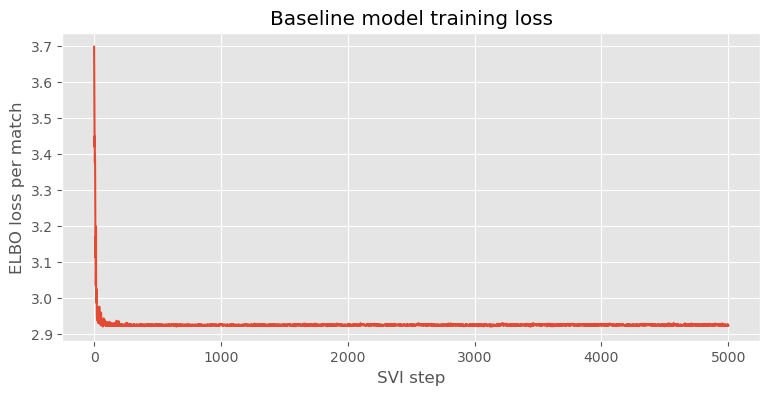

In [4]:
SEED = 42186
NUM_STEPS = 5000
LEARNING_RATE = 0.03

pyro.clear_param_store()
pyro.set_rng_seed(SEED)
torch.manual_seed(SEED)

model = FootballModel(n_teams=num_teams)
guide = AutoDiagonalNormal(model)
optimizer = Adam({"lr": LEARNING_RATE})
svi = SVI(model, guide, optimizer, loss=Trace_ELBO())

svi_losses = []
for step in range(NUM_STEPS):
    loss = svi.step(home_idx_train, away_idx_train, home_goals_train, away_goals_train)
    svi_losses.append(loss / len(train_df))
    if (step + 1) % 500 == 0:
        print(f"Step {step + 1:>5}/{NUM_STEPS} - loss per match: {svi_losses[-1]:.3f}")

assert np.isfinite(svi_losses).all(), "SVI produced non-finite losses."

plt.figure(figsize=(9, 4))
plt.plot(svi_losses)
plt.xlabel("SVI step")
plt.ylabel("ELBO loss per match")
plt.title("Baseline model training loss")
plt.show()


## 5. Posterior predictive match forecasts

We sample scorelines for the retained second-half fixtures. The H/D/A probabilities are empirical frequencies across posterior predictive samples.


In [5]:
NUM_POSTERIOR_SAMPLES = 1000

predictive = Predictive(
    model,
    guide=guide,
    num_samples=NUM_POSTERIOR_SAMPLES,
    return_sites=("obs_home", "obs_away", "team_strengths", "home_adv"),
)
posterior_predictive = predictive(home_idx_second, away_idx_second)

home_goal_samples = posterior_predictive["obs_home"].detach().cpu().numpy()
away_goal_samples = posterior_predictive["obs_away"].detach().cpu().numpy()

assert home_goal_samples.shape == (NUM_POSTERIOR_SAMPLES, len(second_half_2015_df))
assert away_goal_samples.shape == (NUM_POSTERIOR_SAMPLES, len(second_half_2015_df))

home_win_prob = (home_goal_samples > away_goal_samples).mean(axis=0)
draw_prob = (home_goal_samples == away_goal_samples).mean(axis=0)
away_win_prob = (home_goal_samples < away_goal_samples).mean(axis=0)
prob_sums = home_win_prob + draw_prob + away_win_prob
assert np.allclose(prob_sums, 1.0), "H/D/A probabilities must sum to 1 for every match."

actual_result = np.select(
    [
        second_half_2015_df["home_team_goal"].to_numpy() > second_half_2015_df["away_team_goal"].to_numpy(),
        second_half_2015_df["home_team_goal"].to_numpy() == second_half_2015_df["away_team_goal"].to_numpy(),
    ],
    ["H", "D"],
    default="A",
)

prob_matrix = np.column_stack([home_win_prob, draw_prob, away_win_prob])
labels = np.array(["H", "D", "A"])
predicted_result = labels[prob_matrix.argmax(axis=1)]
actual_prob = np.array([
    {"H": h, "D": d, "A": a}[result]
    for result, h, d, a in zip(actual_result, home_win_prob, draw_prob, away_win_prob)
])

match_predictions_second_half = second_half_2015_df[
    ["season", "stage", "date", "home_team", "away_team", "home_team_goal", "away_team_goal"]
].copy()
match_predictions_second_half["actual_result"] = actual_result
match_predictions_second_half["predicted_home_goals_mean"] = home_goal_samples.mean(axis=0)
match_predictions_second_half["predicted_away_goals_mean"] = away_goal_samples.mean(axis=0)
match_predictions_second_half["home_win_prob"] = home_win_prob
match_predictions_second_half["draw_prob"] = draw_prob
match_predictions_second_half["away_win_prob"] = away_win_prob
match_predictions_second_half["predicted_result"] = predicted_result
match_predictions_second_half["actual_result_probability"] = actual_prob
match_predictions_second_half["correct_result"] = (
    match_predictions_second_half["actual_result"] == match_predictions_second_half["predicted_result"]
)

display(match_predictions_second_half.head(20))


,season,stage,date,home_team,away_team,home_team_goal,away_team_goal,actual_result,predicted_home_goals_mean,predicted_away_goals_mean,home_win_prob,draw_prob,away_win_prob,predicted_result,actual_result_probability,correct_result
2850,2015/2016,20,2016-01-02,Arsenal,Newcastle United,1,0,H,2.357,0.691,0.745,0.170,0.085,H,0.745,True
2852,2015/2016,20,2016-01-02,Manchester United,Swansea City,2,1,H,2.270,0.706,0.718,0.177,0.105,H,0.718,True
2853,2015/2016,20,2016-01-02,Norwich City,Southampton,1,0,H,1.160,1.377,0.318,0.258,0.424,A,0.318,False
2854,2015/2016,20,2016-01-02,Sunderland,Aston Villa,3,1,H,1.497,1.078,0.477,0.256,0.267,H,0.477,True
2856,2015/2016,20,2016-01-02,West Bromwich Albion,Stoke City,2,1,H,1.368,1.220,0.415,0.247,0.338,H,0.415,True
2857,2015/2016,20,2016-01-02,West Ham United,Liverpool,2,0,H,1.096,1.542,0.270,0.268,0.462,A,0.270,False
2858,2015/2016,20,2016-01-03,Crystal Palace,Chelsea,0,3,A,1.094,1.497,0.275,0.251,0.474,A,0.474,True
2859,2015/2016,20,2016-01-03,Everton,Tottenham Hotspur,1,1,D,1.536,1.083,0.471,0.249,0.280,H,0.249,False
2860,2015/2016,21,2016-01-12,Aston Villa,Crystal Palace,1,0,H,1.302,1.291,0.374,0.247,0.379,A,0.374,False
2862,2015/2016,21,2016-01-12,Newcastle United,Manchester United,3,3,D,0.890,1.714,0.198,0.228,0.574,A,0.228,False


## 6. First-half table, actual filtered final table, and simulations

Because Bournemouth and Watford are excluded, the retained 18-team season has 34 matches per team: 17 in the first half and 17 in the second half. The simulated final table starts from the actual retained first-half table and adds sampled second-half results.


In [6]:
retained_2015_teams = sorted(set(season_2015_df["home_team"]).union(season_2015_df["away_team"]))
assert not (set(retained_2015_teams) & EXCLUDED_TEAMS)
assert len(retained_2015_teams) == 18


def empty_table(teams):
    return {
        team: {
            "team": team,
            "played": 0,
            "wins": 0,
            "draws": 0,
            "losses": 0,
            "goals_for": 0,
            "goals_against": 0,
            "goal_difference": 0,
            "points": 0,
        }
        for team in teams
    }


def add_result(table, home_team, away_team, home_goals, away_goals):
    home_goals = int(home_goals)
    away_goals = int(away_goals)

    table[home_team]["played"] += 1
    table[away_team]["played"] += 1
    table[home_team]["goals_for"] += home_goals
    table[home_team]["goals_against"] += away_goals
    table[away_team]["goals_for"] += away_goals
    table[away_team]["goals_against"] += home_goals

    if home_goals > away_goals:
        table[home_team]["wins"] += 1
        table[away_team]["losses"] += 1
        table[home_team]["points"] += 3
    elif home_goals == away_goals:
        table[home_team]["draws"] += 1
        table[away_team]["draws"] += 1
        table[home_team]["points"] += 1
        table[away_team]["points"] += 1
    else:
        table[away_team]["wins"] += 1
        table[home_team]["losses"] += 1
        table[away_team]["points"] += 3

    table[home_team]["goal_difference"] = table[home_team]["goals_for"] - table[home_team]["goals_against"]
    table[away_team]["goal_difference"] = table[away_team]["goals_for"] - table[away_team]["goals_against"]


def table_from_matches(matches_df, teams):
    table = empty_table(teams)
    for row in matches_df.itertuples(index=False):
        add_result(table, row.home_team, row.away_team, row.home_team_goal, row.away_team_goal)
    return rank_table(pd.DataFrame(table.values()))


def rank_table(table_df):
    table_df = table_df.copy()
    table_df = table_df.sort_values(
        ["points", "goal_difference", "goals_for", "team"],
        ascending=[False, False, False, True],
    ).reset_index(drop=True)
    table_df.insert(0, "rank", np.arange(1, len(table_df) + 1))
    return table_df


first_half_table = table_from_matches(first_half_2015_df, retained_2015_teams)
actual_final_table = table_from_matches(season_2015_df, retained_2015_teams)

assert (first_half_table["played"] == 17).all(), "Each retained team should have 17 first-half matches."
assert (actual_final_table["played"] == 34).all(), "Each retained team should have 34 retained-season matches."

display(first_half_table)
display(actual_final_table)


,rank,team,played,wins,draws,losses,goals_for,goals_against,goal_difference,points
0,1,Leicester City,17,10,5,2,34,23,11,35
1,2,Arsenal,17,10,3,4,28,18,10,33
2,3,Manchester City,17,9,3,5,30,19,11,30
3,4,Tottenham Hotspur,17,7,8,2,26,13,13,29
4,5,West Ham United,17,7,8,2,25,17,8,29
5,6,Crystal Palace,17,8,3,6,22,16,6,27
6,7,Manchester United,17,7,6,4,19,13,6,27
7,8,Liverpool,17,7,6,4,21,19,2,27
8,9,Stoke City,17,7,5,5,18,16,2,26
9,10,Everton,17,6,6,5,30,23,7,24


,rank,team,played,wins,draws,losses,goals_for,goals_against,goal_difference,points
0,1,Leicester City,34,21,10,3,64,34,30,73
1,2,Arsenal,34,16,11,7,54,36,18,59
2,3,Tottenham Hotspur,34,15,13,6,58,33,25,58
3,4,Manchester United,34,16,9,9,42,31,11,57
4,5,Southampton,34,16,8,10,55,39,16,56
5,6,West Ham United,34,14,14,6,56,43,13,56
6,7,Manchester City,34,15,9,10,58,39,19,54
7,8,Liverpool,34,13,12,9,58,46,12,51
8,9,Chelsea,34,11,12,11,53,49,4,45
9,10,Swansea City,34,11,10,13,37,46,-9,43


In [7]:
simulated_table_rows = []

for sample_id in range(NUM_POSTERIOR_SAMPLES):
    table = empty_table(retained_2015_teams)

    for row in first_half_2015_df.itertuples(index=False):
        add_result(table, row.home_team, row.away_team, row.home_team_goal, row.away_team_goal)

    for match_idx, row in enumerate(second_half_2015_df.itertuples(index=False)):
        add_result(
            table,
            row.home_team,
            row.away_team,
            home_goal_samples[sample_id, match_idx],
            away_goal_samples[sample_id, match_idx],
        )

    sample_table = rank_table(pd.DataFrame(table.values()))
    assert (sample_table["played"] == 34).all(), "Every simulated retained team should have 34 matches."
    sample_table["sample_id"] = sample_id
    simulated_table_rows.append(sample_table)

simulated_tables = pd.concat(simulated_table_rows, ignore_index=True)

predicted_final_table = (
    simulated_tables.groupby("team")
    .agg(
        expected_points=("points", "mean"),
        points_p05=("points", lambda x: np.quantile(x, 0.05)),
        points_p95=("points", lambda x: np.quantile(x, 0.95)),
        expected_goal_difference=("goal_difference", "mean"),
        mean_rank=("rank", "mean"),
        rank_p05=("rank", lambda x: np.quantile(x, 0.05)),
        rank_p95=("rank", lambda x: np.quantile(x, 0.95)),
        title_probability=("rank", lambda x: np.mean(x == 1)),
        top4_probability=("rank", lambda x: np.mean(x <= 4)),
    )
    .reset_index()
)

predicted_final_table = predicted_final_table.merge(
    actual_final_table[["team", "rank", "points", "goal_difference"]].rename(
        columns={
            "rank": "actual_rank",
            "points": "actual_points",
            "goal_difference": "actual_goal_difference",
        }
    ),
    on="team",
    how="left",
)

predicted_final_table["points_error"] = (
    predicted_final_table["expected_points"] - predicted_final_table["actual_points"]
)
predicted_final_table["rank_error"] = (
    predicted_final_table["mean_rank"] - predicted_final_table["actual_rank"]
)
predicted_final_table = predicted_final_table.sort_values(
    ["expected_points", "expected_goal_difference", "team"],
    ascending=[False, False, True],
).reset_index(drop=True)
predicted_final_table.insert(0, "predicted_rank", np.arange(1, len(predicted_final_table) + 1))

display(predicted_final_table)


,predicted_rank,team,expected_points,points_p05,points_p95,expected_goal_difference,mean_rank,rank_p05,rank_p95,title_probability,top4_probability,actual_rank,actual_points,actual_goal_difference,points_error,rank_error
0,1,Arsenal,64.158,56.00,72.00,22.207,2.289,1.00,5.0,0.387,0.916,2,59,18,5.158,0.289
1,2,Manchester City,62.517,54.00,71.00,25.274,2.739,1.00,6.0,0.288,0.861,7,54,19,8.517,-4.261
2,3,Manchester United,59.551,50.95,68.00,20.276,3.752,1.00,8.0,0.138,0.689,4,57,11,2.551,-0.248
3,4,Leicester City,59.265,49.00,69.00,11.799,4.116,1.00,8.0,0.119,0.617,1,73,30,-13.735,3.116
4,5,Liverpool,55.753,47.00,64.00,10.219,5.511,2.00,10.0,0.034,0.358,8,51,12,4.753,-2.489
5,6,Tottenham Hotspur,54.048,46.00,63.00,15.432,6.138,2.00,11.0,0.024,0.255,3,58,25,-3.952,3.138
6,7,Chelsea,51.066,43.00,59.00,8.717,7.614,3.00,12.0,0.000,0.114,9,45,4,6.066,-1.386
7,8,Everton,49.099,41.00,58.00,9.536,8.487,4.00,13.0,0.004,0.063,12,41,3,8.099,-3.513
8,9,Crystal Palace,48.936,40.00,58.00,3.465,8.755,4.00,13.0,0.005,0.053,14,38,-11,10.936,-5.245
9,10,West Ham United,48.056,40.00,57.00,1.249,9.177,4.95,13.0,0.001,0.050,6,56,13,-7.944,3.177


## 7. Visualizing inferred strengths and forecast quality

The next plots summarize what the baseline model learned and how its mid-season forecast compares with the retained actual 2015/2016 outcome.


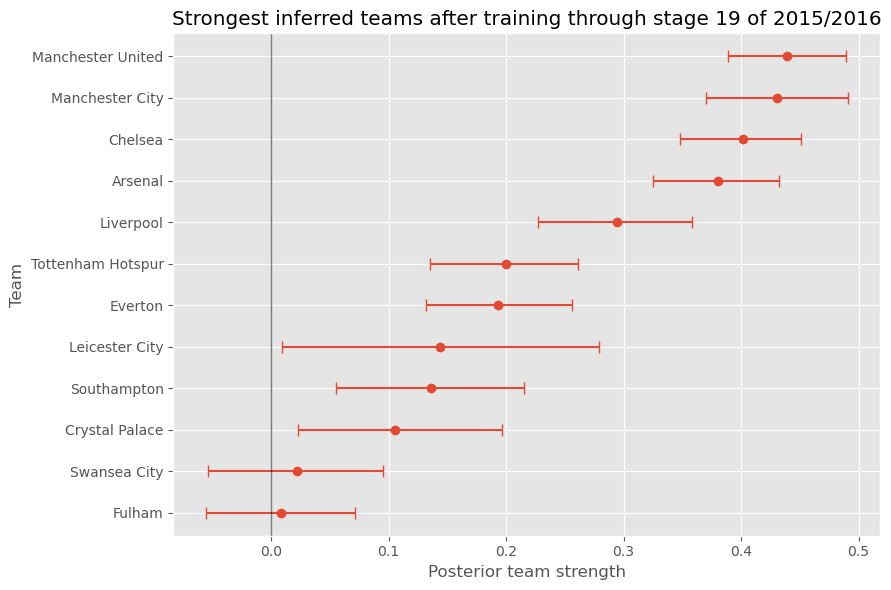

,team,strength_mean,strength_p05,strength_p95
16,Manchester United,0.439134,0.388902,0.489443
15,Manchester City,0.430414,0.369808,0.490863
8,Chelsea,0.401758,0.348231,0.450918
0,Arsenal,0.380461,0.324886,0.432124
14,Liverpool,0.294369,0.226800,0.357814
27,Tottenham Hotspur,0.200110,0.135588,0.260982
10,Everton,0.192858,0.131703,0.255799
13,Leicester City,0.143604,0.009716,0.278772
23,Southampton,0.136330,0.055272,0.215210
9,Crystal Palace,0.105523,0.022824,0.196579


In [8]:
# Plot the strongest teams according to the inferred latent team-strength posterior.
team_strength_samples = posterior_predictive["team_strengths"].detach().cpu().numpy()

team_strength_summary = pd.DataFrame(
    {
        "team": [idx_to_team[idx] for idx in range(num_teams)],
        "strength_mean": team_strength_samples.mean(axis=0),
        "strength_p05": np.quantile(team_strength_samples, 0.05, axis=0),
        "strength_p95": np.quantile(team_strength_samples, 0.95, axis=0),
    }
).sort_values("strength_mean", ascending=False)

top_strengths = team_strength_summary.head(12).sort_values("strength_mean")

plt.figure(figsize=(9, 6))
plt.errorbar(
    top_strengths["strength_mean"],
    top_strengths["team"],
    xerr=[
        top_strengths["strength_mean"] - top_strengths["strength_p05"],
        top_strengths["strength_p95"] - top_strengths["strength_mean"],
    ],
    fmt="o",
    capsize=4,
)
plt.axvline(0, color="black", linewidth=1, alpha=0.5)
plt.xlabel("Posterior team strength")
plt.ylabel("Team")
plt.title("Strongest inferred teams after training through stage 19 of 2015/2016")
plt.tight_layout()
plt.show()

display(team_strength_summary.head(12))


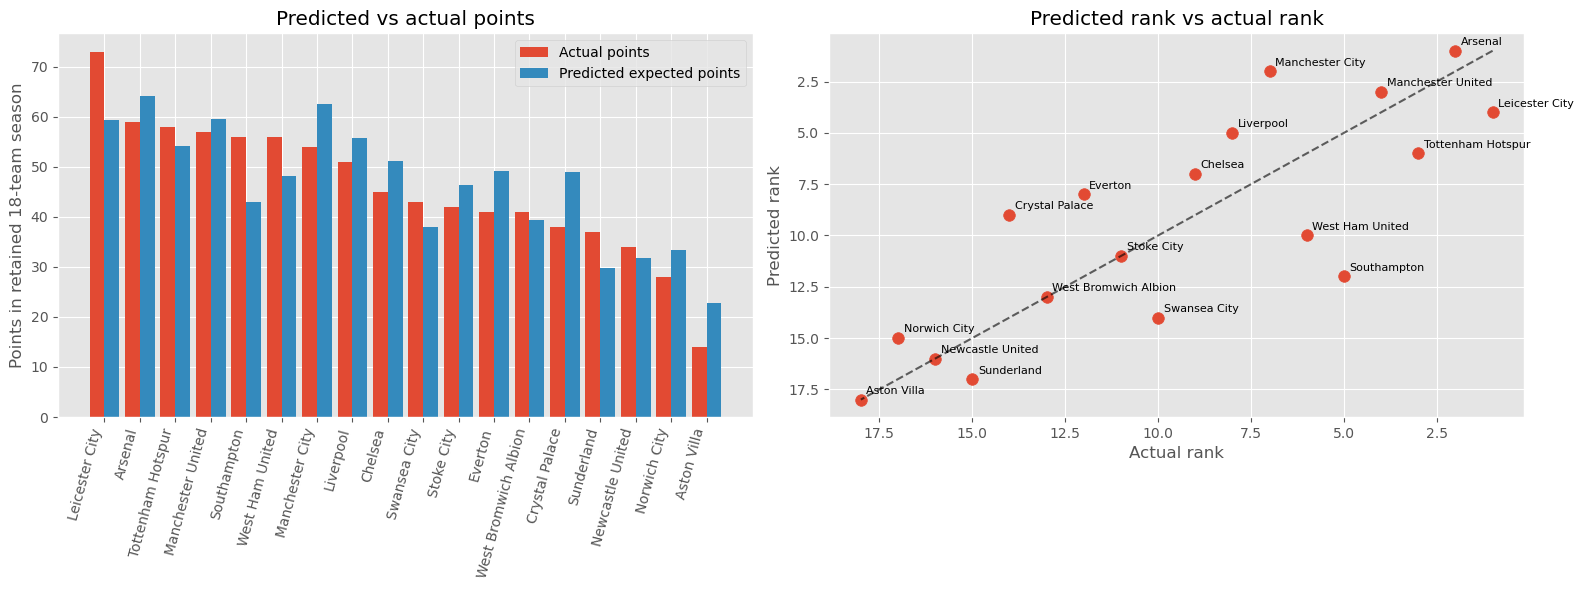

,team,actual_rank,predicted_rank,actual_points,expected_points,points_error,rank_error
3,Leicester City,1,4,73,59.265,-13.735,3.116
0,Arsenal,2,1,59,64.158,5.158,0.289
5,Tottenham Hotspur,3,6,58,54.048,-3.952,3.138
2,Manchester United,4,3,57,59.551,2.551,-0.248
11,Southampton,5,12,56,43.021,-12.979,6.326
9,West Ham United,6,10,56,48.056,-7.944,3.177
1,Manchester City,7,2,54,62.517,8.517,-4.261
4,Liverpool,8,5,51,55.753,4.753,-2.489
6,Chelsea,9,7,45,51.066,6.066,-1.386
13,Swansea City,10,14,43,37.937,-5.063,3.513


In [9]:
# Plot predicted final outcome against the actual retained 2015/2016 outcome.
comparison_table = predicted_final_table.sort_values("actual_rank").copy()
comparison_table["team_label"] = comparison_table["team"]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

x = np.arange(len(comparison_table))
bar_width = 0.42
axes[0].bar(
    x - bar_width / 2,
    comparison_table["actual_points"],
    width=bar_width,
    label="Actual points",
)
axes[0].bar(
    x + bar_width / 2,
    comparison_table["expected_points"],
    width=bar_width,
    label="Predicted expected points",
)
axes[0].set_xticks(x)
axes[0].set_xticklabels(comparison_table["team_label"], rotation=75, ha="right")
axes[0].set_ylabel("Points in retained 18-team season")
axes[0].set_title("Predicted vs actual points")
axes[0].legend()

axes[1].scatter(
    comparison_table["actual_rank"],
    comparison_table["predicted_rank"],
    s=70,
)
for row in comparison_table.itertuples(index=False):
    axes[1].annotate(
        row.team,
        (row.actual_rank, row.predicted_rank),
        textcoords="offset points",
        xytext=(4, 4),
        fontsize=8,
    )
max_rank = len(comparison_table)
axes[1].plot([1, max_rank], [1, max_rank], linestyle="--", color="black", alpha=0.6)
axes[1].invert_xaxis()
axes[1].invert_yaxis()
axes[1].set_xlabel("Actual rank")
axes[1].set_ylabel("Predicted rank")
axes[1].set_title("Predicted rank vs actual rank")

plt.tight_layout()
plt.show()

display(
    comparison_table[
        [
            "team",
            "actual_rank",
            "predicted_rank",
            "actual_points",
            "expected_points",
            "points_error",
            "rank_error",
        ]
    ]
)


## 8. Evaluation



In [10]:
EPS = 1e-12
second_half_accuracy = match_predictions_second_half["correct_result"].mean()
second_half_nll = -np.log(np.clip(match_predictions_second_half["actual_result_probability"], EPS, 1.0)).mean()

table_mae_points = predicted_final_table["points_error"].abs().mean()
table_mae_rank = predicted_final_table["rank_error"].abs().mean()

evaluation_summary = pd.DataFrame(
    [
        {"metric": "second_half_result_accuracy", "value": second_half_accuracy},
        {"metric": "second_half_hda_negative_log_likelihood", "value": second_half_nll},
        {"metric": "final_table_points_mae", "value": table_mae_points},
        {"metric": "final_table_rank_mae", "value": table_mae_rank},
        {"metric": "forecast_matches", "value": len(second_half_2015_df)},
        {"metric": "retained_teams", "value": len(retained_2015_teams)},
    ]
)

display(evaluation_summary)
display(
    match_predictions_second_half[
        [
            "stage",
            "date",
            "home_team",
            "away_team",
            "home_team_goal",
            "away_team_goal",
            "actual_result",
            "predicted_result",
            "home_win_prob",
            "draw_prob",
            "away_win_prob",
            "correct_result",
        ]
    ].head(30)
)


,metric,value
0,second_half_result_accuracy,0.431373
1,second_half_hda_negative_log_likelihood,1.054599
2,final_table_points_mae,6.648333
3,final_table_rank_mae,2.313222
4,forecast_matches,153.000000
5,retained_teams,18.000000


,stage,date,home_team,away_team,home_team_goal,away_team_goal,actual_result,predicted_result,home_win_prob,draw_prob,away_win_prob,correct_result
2850,20,2016-01-02,Arsenal,Newcastle United,1,0,H,H,0.745,0.170,0.085,True
2852,20,2016-01-02,Manchester United,Swansea City,2,1,H,H,0.718,0.177,0.105,True
2853,20,2016-01-02,Norwich City,Southampton,1,0,H,A,0.318,0.258,0.424,False
2854,20,2016-01-02,Sunderland,Aston Villa,3,1,H,H,0.477,0.256,0.267,True
2856,20,2016-01-02,West Bromwich Albion,Stoke City,2,1,H,H,0.415,0.247,0.338,True
2857,20,2016-01-02,West Ham United,Liverpool,2,0,H,A,0.270,0.268,0.462,False
2858,20,2016-01-03,Crystal Palace,Chelsea,0,3,A,A,0.275,0.251,0.474,True
2859,20,2016-01-03,Everton,Tottenham Hotspur,1,1,D,H,0.471,0.249,0.280,False
2860,21,2016-01-12,Aston Villa,Crystal Palace,1,0,H,A,0.374,0.247,0.379,False
2862,21,2016-01-12,Newcastle United,Manchester United,3,3,D,A,0.198,0.228,0.574,False


## 9. Result analysis

This cell turns the numerical outputs into a short interpretation. Because it reads from the fitted model outputs above, rerunning the model will automatically update the analysis.


In [11]:
from IPython.display import Markdown, display


def metric_value(metric_name):
    value = evaluation_summary.loc[
        evaluation_summary["metric"] == metric_name,
        "value",
    ].iloc[0]
    return float(value)


accuracy = metric_value("second_half_result_accuracy")
nll = metric_value("second_half_hda_negative_log_likelihood")
points_mae = metric_value("final_table_points_mae")
rank_mae = metric_value("final_table_rank_mae")

top_strength = team_strength_summary.head(5).copy()
top_expected = predicted_final_table.head(5).copy()
largest_overprediction = predicted_final_table.sort_values("points_error", ascending=False).head(3)
largest_underprediction = predicted_final_table.sort_values("points_error", ascending=True).head(3)
largest_rank_misses = (
    predicted_final_table.assign(abs_rank_error=predicted_final_table["rank_error"].abs())
    .sort_values("abs_rank_error", ascending=False)
    .head(3)
)

winner_row = predicted_final_table.iloc[0]
actual_winner_row = actual_final_table.iloc[0]

analysis_text = f'''
### Baseline model interpretation

The baseline model predicts the retained second half with an H/D/A accuracy of **{accuracy:.1%}** and an average H/D/A negative log likelihood of **{nll:.3f}**. Since the model only knows team strength and home advantage, this is best interpreted as a simple probabilistic benchmark rather than a fully informed football forecasting model.

The strongest inferred teams after training through stage 19 are **{", ".join(top_strength["team"].tolist())}**. These strengths summarize long-run scoring performance in the training data, so they tend to reward historically strong teams and may react slowly to unusual single-season stories.

The model's most likely filtered-season winner is **{winner_row["team"]}** with **{winner_row["expected_points"]:.1f}** expected points. The actual retained-season winner is **{actual_winner_row["team"]}** with **{actual_winner_row["points"]:.0f}** points.

Across the filtered 18-team final table, the mean absolute points error is **{points_mae:.2f}** and the mean absolute rank error is **{rank_mae:.2f}** positions. This gives a compact measure of how well the model turns mid-season information into a final-table forecast.

The biggest points over-predictions are **{", ".join(largest_overprediction["team"].tolist())}**. The biggest points under-predictions are **{", ".join(largest_underprediction["team"].tolist())}**. The largest rank misses are **{", ".join(largest_rank_misses["team"].tolist())}**.

Overall, this baseline is useful for the report because its mistakes are interpretable: it can learn broad team quality and home advantage, but it cannot capture player availability, tactical changes, betting-market information, team-specific attack/defense balance, or time-varying form.
'''

display(Markdown(analysis_text))

display(
    top_expected[
        [
            "predicted_rank",
            "team",
            "expected_points",
            "actual_rank",
            "actual_points",
            "points_error",
            "rank_error",
            "title_probability",
            "top4_probability",
        ]
    ]
)



### Baseline model interpretation

The baseline model predicts the retained second half with an H/D/A accuracy of **43.1%** and an average H/D/A negative log likelihood of **1.055**. Since the model only knows team strength and home advantage, this is best interpreted as a simple probabilistic benchmark rather than a fully informed football forecasting model.

The strongest inferred teams after training through stage 19 are **Manchester United, Manchester City, Chelsea, Arsenal, Liverpool**. These strengths summarize long-run scoring performance in the training data, so they tend to reward historically strong teams and may react slowly to unusual single-season stories.

The model's most likely filtered-season winner is **Arsenal** with **64.2** expected points. The actual retained-season winner is **Leicester City** with **73** points.

Across the filtered 18-team final table, the mean absolute points error is **6.65** and the mean absolute rank error is **2.31** positions. This gives a compact measure of how well the model turns mid-season information into a final-table forecast.

The biggest points over-predictions are **Crystal Palace, Aston Villa, Manchester City**. The biggest points under-predictions are **Leicester City, Southampton, West Ham United**. The largest rank misses are **Southampton, Crystal Palace, Manchester City**.

Overall, this baseline is useful for the report because its mistakes are interpretable: it can learn broad team quality and home advantage, but it cannot capture player availability, tactical changes, betting-market information, team-specific attack/defense balance, or time-varying form.


,predicted_rank,team,expected_points,actual_rank,actual_points,points_error,rank_error,title_probability,top4_probability
0,1,Arsenal,64.158,2,59,5.158,0.289,0.387,0.916
1,2,Manchester City,62.517,7,54,8.517,-4.261,0.288,0.861
2,3,Manchester United,59.551,4,57,2.551,-0.248,0.138,0.689
3,4,Leicester City,59.265,1,73,-13.735,3.116,0.119,0.617
4,5,Liverpool,55.753,8,51,4.753,-2.489,0.034,0.358


## 10. Export results

The exports below are optional project artifacts. They contain the retained second-half match forecasts and the Bournemouth/Watford-excluded mid-season table forecast.


In [12]:
match_predictions_path = DATA_DIR / "epl_2015_second_half_predictions.csv"
predicted_table_path = DATA_DIR / "epl_2015_midseason_predicted_table.csv"

match_predictions_second_half.to_csv(match_predictions_path, index=False)
predicted_final_table.to_csv(predicted_table_path, index=False)

print(f"Saved match predictions to: {match_predictions_path}")
print(f"Saved predicted final table to: {predicted_table_path}")


Saved match predictions to: C:\Users\Madsl\Dropbox\DTU\Kand\3.Semester\MBML\Project_MBML\data\epl_2015_second_half_predictions.csv
Saved predicted final table to: C:\Users\Madsl\Dropbox\DTU\Kand\3.Semester\MBML\Project_MBML\data\epl_2015_midseason_predicted_table.csv


## 11. Interpretation notes

This baseline is useful because it is transparent: all predictions flow through latent team strengths and home advantage. It is also intentionally limited. The model does not use player attributes, betting odds, injuries, time-varying form, separate attack/defense strengths, or any explicit promotion/relegation mechanism.

Because Bournemouth and Watford are excluded, the final table here is not the official 20-team 2015/2016 Premier League table. It is an 18-team complete-case baseline table designed to avoid prior-only predictions for teams without historical EPL observations in the training window.
